# **Micrograd**

It is a tiny Autograd engine.
- Autograd is Automatic Gradient

It implements backpropogation over a dynamically built DAG ans a small neural networks library on top of it with a PyTorch-like API. 
Both are tiny, but it is enough to build up entire deep neural nets doing binary classification.

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
def f(x):
    return 3*x**2 - 4*x + 5 # A simple quadratic function which makes a Parabola. 

In [4]:
f(5)

60

In [5]:
xs = np.arange(-5, 5, 0.25) # A range of x values from -5 to 5 with a step of 0.25
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [6]:
ys = f(xs) # Compute the corresponding y values for each x using the function f
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

Text(0.5, 1.0, 'Plot of the function f(x)')

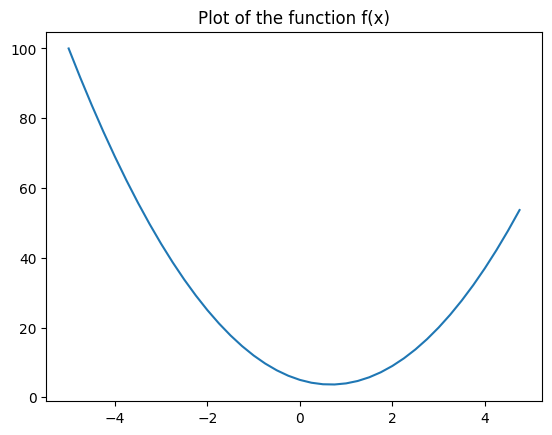

In [7]:
plt.plot(xs, ys) # Plot the x and y values to visualize the function
plt.title('Plot of the function f(x)')

In [29]:
class Value:
    def __init__(self, data, _children =(), _op='', label=''):
        self.data = data
        self.grad = 0.0 # Gradient of this value with respect to some loss function
        self._backward = lambda: None # Function to compute the gradient of this value with respect to its children
        self._prev = set(_children) # Set of child nodes that contributed to this value
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data= {self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) # Ensure that other is a Value instance
        out = Value(self.data + other.data, (self, other)) # Create a new Value for the sum and store the child nodes
        def _backward():
            self.grad += out.grad * 1.0 # The gradient of the sum with respect to self is 1
            other.grad += out.grad * 1.0 # The gradient of the sum with respect to other is 1
        out._backward = _backward # Assign the backward function to the output Value
        return out
    
    def __mul__(self, other):        
        other = other if isinstance(other, Value) else Value(other) # Ensure that other is a Value instance

        out = Value(self.data * other.data, (self, other)) # Create a new Value for the product and store the child nodes
        def _backward():
            self.grad += out.grad * other.data # The gradient of the product with respect to self is other.data
            other.grad += out.grad * self.data # The gradient of the product with respect to other is self.data
        out._backward = _backward # Assign the backward function to the output Value
        return out
    
    def __rmul__(self, other):
        return self * other # This allows for scalar multiplication from the left (e.g., 2 * Value)
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "Only supporting int/float powers for now" # Ensure that the exponent is a number
        out = Value(self.data ** other, (self, ), f'**{other}') # Create a new Value for the power and store the child node
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad # The gradient of the power with respect to self is other * self.data^(other - 1)
        out._backward = _backward # Assign the backward function to the output Value
        return out
    
    def __truediv__(self, other):
        return self * other**-1 # Division is implemented as multiplication by the reciprocal
    
    def __neg__(self):
        return self * -1 # Negation is implemented as multiplication by -1
    
    def __sub__(self, other):
        return self + (-other) # Subtraction is implemented as addition of the negation

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad # The gradient of tanh with respect to self is (1 - t^2)
        out._backward = _backward # Assign the backward function to the output Value
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp') # Create a new Value for the exponential and store the child node
        def _backward():
            self.grad += out.data * out.grad # The gradient of exp with respect to self is exp(self.data)
        out._backward = _backward # Assign the backward function to the output Value
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [30]:
a = Value(2.0, label='a')
b = Value(4.0, label='b')
a-b

Value(data= -2.0)

In [10]:
from graphviz import Digraph

def trace(root):
    # Builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format = 'svg', graph_attr={'rankdir': 'LR'}) # Create a new directed graph with left-to-right orientation
    
    nodes, edges = trace(root) # Get all nodes and edges in the graph
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" %  (n.label, n.data, n.grad), shape = 'record') # Add a node to the graph with a label showing its data value
        if n._op:
            dot.node(name = uid + n._op, label = n._op) # Add a node for the operation that produced this value
            dot.edge(uid + n._op, uid) # Connect the operation node to the value node
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))) # Connect the child nodes to their parent nodes in the graph
    
    return dot

In [33]:
# Inputs 
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# Weights and bias
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')

# Summation of weighted inputs and bias
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'

# Final output of the neuron
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

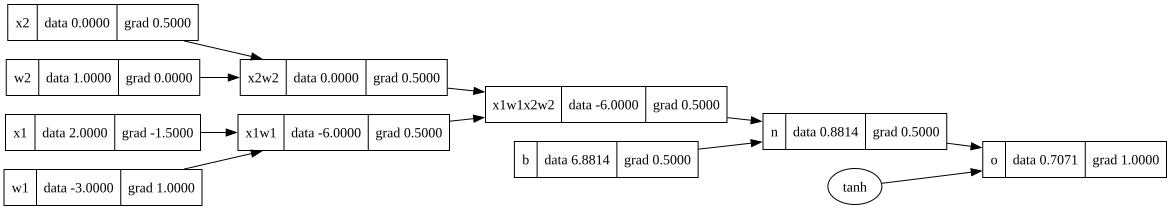

In [34]:
draw_dot(o)